
FINAL PS2 MAIN RESULTS
       mechanism      condition  primary_fan_allocation  final_fan_ownership  fan_consumer_surplus  scalper_profit  rent_dissipation  social_surplus  mean_fan_effort  mean_scalper_effort  active_fans  active_scalpers  scalper_identities
  Effort Contest          No AI                   1.000                  1.0                 9.716           0.000           145.123         109.716            0.073                0.000       21.363              0.0                 NaN
  Effort Contest AI stress test                   0.000                  1.0                79.303           1.600            78.400         180.903            0.000                1.568        0.000             50.0                 NaN
Verified Lottery          No AI                   0.797                  1.0                87.389          16.208             0.000         203.597              NaN                  NaN          NaN              NaN                 1.0
Verified Lottery AI stress t

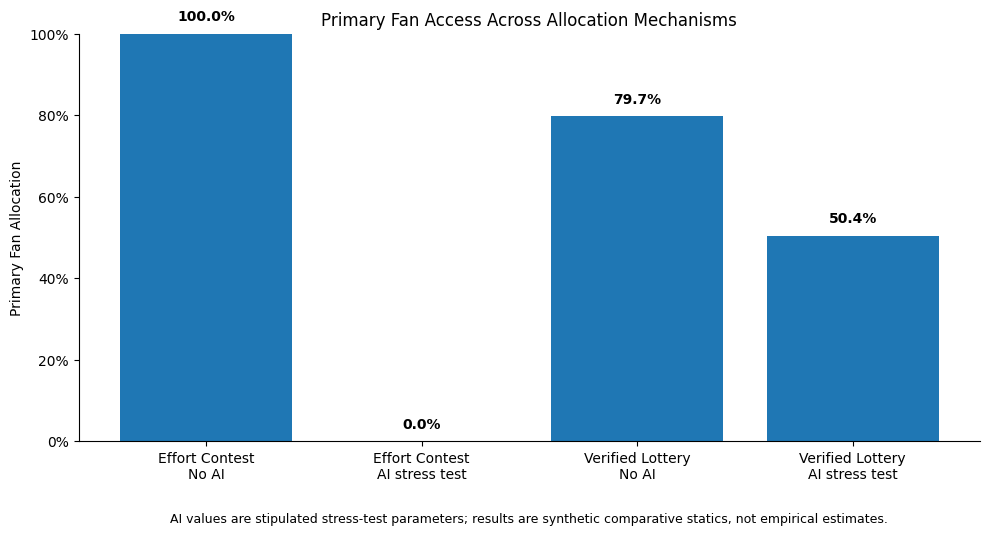

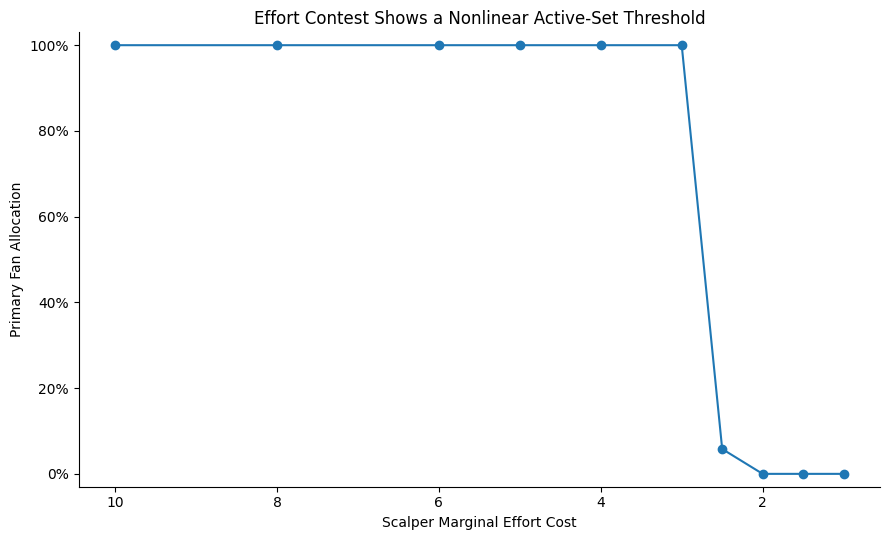

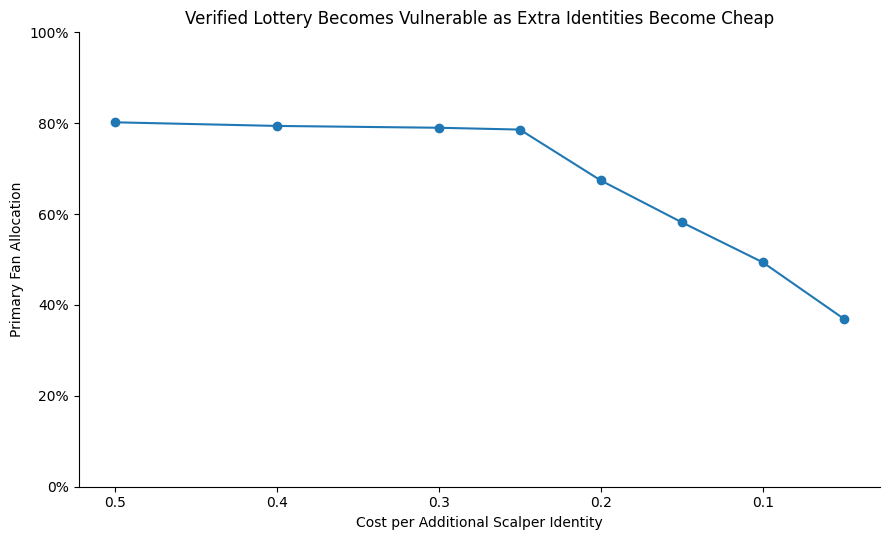

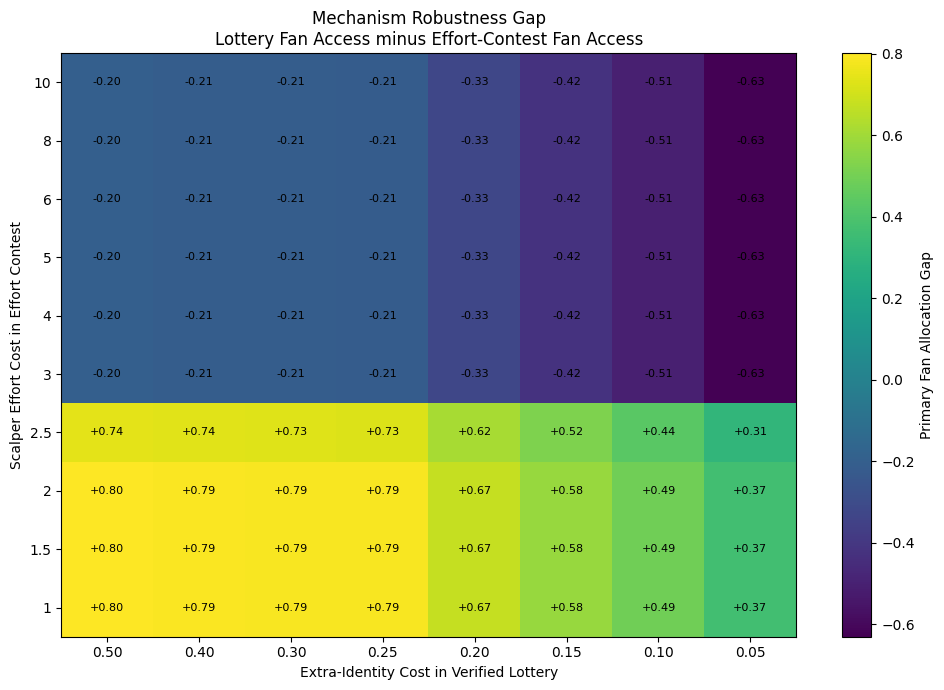

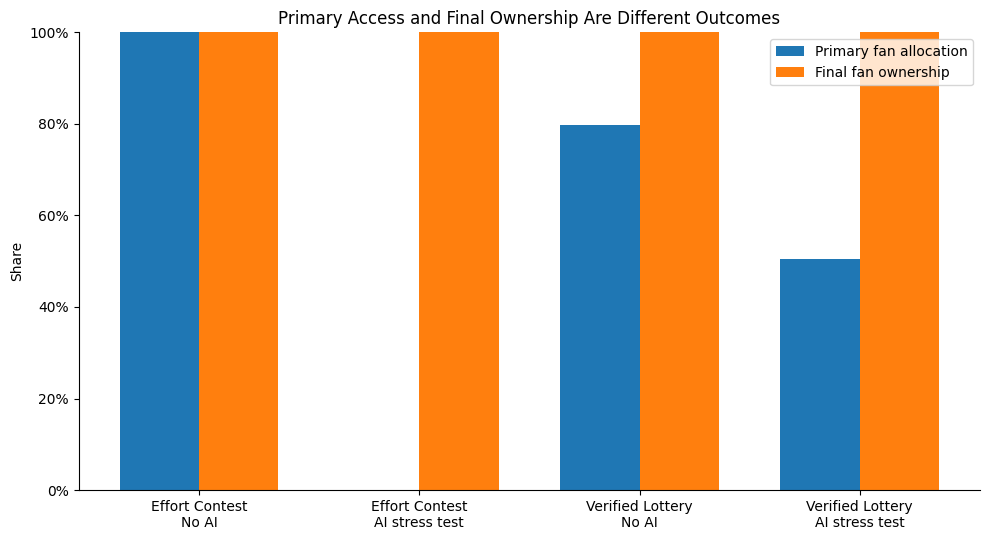


FINAL REPRODUCIBILITY RECORD
Random seed: 2026
Main simulations per condition: 5000
Sensitivity simulations per value: 500
Genuine fans: 200
Scalpers: 50
Official ticket price: 100.0
Resale price: 180.0

Main mechanisms:
1. Effort Contest
2. Verified Lottery

Main Effort Contest conditions:
No AI: (c_F, c_S) = (10, 10)
AI stress test: (c_F, c_S) = (5, 1)

Main Verified Lottery conditions:
No AI identity cost: 0.25
AI stress-test identity cost: 0.1

Saved tables:
- simulation_results.csv
- summary_results.csv
- tullock_hand_check.csv
- effort_cost_sweep_summary.csv
- identity_cost_sweep_summary.csv
- joint_robustness_map.csv

Saved figures:
- figures/figure1_primary_fan_allocation.png
- figures/figure2_effort_threshold.png
- figures/figure3_identity_sensitivity.png
- figures/figure4_joint_robustness_map.png
- figures/figure5_primary_vs_final.png

Runtime: 10.81 seconds

EVIDENCE BOUNDARY:
All market values and AI-induced cost changes are synthetic or stipulated.
The AI treatment is a m

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# COMSCI / ECON 206 PS2 FINAL
# AI, Rent-Seeking, and Ticket Allocation:
# Mechanism Design under Asymmetric Participation Costs
#
# Research question:
# How does AI's asymmetric reduction of ticket-buying costs
# change strategic competition and welfare, and which
# allocation mechanism is more robust to this change?
#
# Mechanisms:
# 1. Effort Contest: heterogeneous single-prize Tullock contest
# 2. Verified Lottery: random allocation with costly extra identities
#
# FINAL REVISION:
# - Keeps the original AI treatment as a stress test
# - Adds one-dimensional sensitivity analysis
# - Adds a joint robustness map
# - Separates primary allocation from final ownership
# - Reports welfare, rent dissipation, and private surplus separately
# - Treats all AI cost parameters as stipulated rather than empirical
# ============================================================


# ============================================================
# 1. Reproducibility and global parameters
# ============================================================

RANDOM_SEED = 2026

N_FANS = 200
N_SCALPERS = 50

TICKET_PRICE = 100.0
RESALE_PRICE = 180.0

FAN_VALUE_LOW = 120.0
FAN_VALUE_HIGH = 260.0

# Main simulation
N_SIMULATIONS = 5000

# Sensitivity analysis
N_SENSITIVITY = 500

# ------------------------------------------------------------
# Effort Contest
# ------------------------------------------------------------

# No-AI benchmark
EFFORT_NO_AI_FAN_COST = 10.0
EFFORT_NO_AI_SCALPER_COST = 10.0

# AI stress-test treatment
#
# IMPORTANT:
# These are stipulated stress-test parameters.
# They are NOT empirical estimates of real ticket markets.
EFFORT_AI_FAN_COST = 5.0
EFFORT_AI_SCALPER_COST = 1.0

# ------------------------------------------------------------
# Verified Lottery
# ------------------------------------------------------------

LOTTERY_NO_AI_IDENTITY_COST = 0.25
LOTTERY_AI_IDENTITY_COST = 0.10

MAX_SCALPER_IDENTITIES = 8

# ------------------------------------------------------------
# Sensitivity grids
# ------------------------------------------------------------

EFFORT_COST_GRID = [
    10.0,
    8.0,
    6.0,
    5.0,
    4.0,
    3.0,
    2.5,
    2.0,
    1.5,
    1.0
]

IDENTITY_COST_GRID = [
    0.50,
    0.40,
    0.30,
    0.25,
    0.20,
    0.15,
    0.10,
    0.05
]

os.makedirs("figures", exist_ok=True)

start_time = time.time()


# ============================================================
# 2. Exact heterogeneous Tullock equilibrium
# ============================================================

def heterogeneous_tullock_equilibrium(
    values,
    costs,
    tolerance=1e-12
):
    """
    Solve the complete-information heterogeneous
    single-prize Tullock contest.

    Player i has:
        prize value V_i
        marginal effort cost c_i

    Utility:
        u_i = V_i * e_i / sum_j(e_j) - c_i * e_i

    Let:
        x_i = c_i / V_i

    For an active set A of size m:
        E = (m - 1) / sum_{i in A}(x_i)

        e_i = E * (1 - x_i * E)

    If implied effort is non-positive, that player is
    removed from the active set and the equilibrium
    is recomputed.

    This is used as a tractable complete-information
    Nash benchmark after simulated values are realized.
    """

    values = np.asarray(values, dtype=float)
    costs = np.asarray(costs, dtype=float)

    if np.any(values <= 0):
        raise ValueError(
            "All contest prize values must be positive."
        )

    if np.any(costs <= 0):
        raise ValueError(
            "All marginal effort costs must be positive."
        )

    x = costs / values

    active = np.arange(len(values))

    while len(active) >= 2:

        active_x = x[active]

        m = len(active)

        total_effort = (
            (m - 1)
            / active_x.sum()
        )

        active_effort = (
            total_effort
            * (
                1
                - active_x
                * total_effort
            )
        )

        positive = (
            active_effort
            > tolerance
        )

        if positive.all():

            effort = np.zeros(
                len(values)
            )

            effort[active] = (
                active_effort
            )

            return (
                effort,
                total_effort,
                active
            )

        active = active[
            positive
        ]

    effort = np.zeros(
        len(values)
    )

    return (
        effort,
        0.0,
        active
    )


# ============================================================
# 3. One Effort Contest market
# ============================================================

def run_effort_market(
    rng,
    c_fan,
    c_scalper
):
    """
    Simulate one representative scarce ticket.

    Genuine fans:
        attendance value ~ Uniform[120, 260]
        contest prize value = attendance value - official price

    Scalpers:
        contest prize value = resale price - official price

    Everyone observes the realized values in this
    tractable complete-information benchmark.

    The winner is sampled using equilibrium effort shares.
    """

    fan_values = rng.uniform(
        FAN_VALUE_LOW,
        FAN_VALUE_HIGH,
        N_FANS
    )

    fan_prize_values = (
        fan_values
        - TICKET_PRICE
    )

    scalper_prize_value = (
        RESALE_PRICE
        - TICKET_PRICE
    )

    scalper_values = np.full(
        N_SCALPERS,
        scalper_prize_value
    )

    contest_values = np.concatenate([
        fan_prize_values,
        scalper_values
    ])

    contest_costs = np.concatenate([
        np.full(
            N_FANS,
            c_fan
        ),
        np.full(
            N_SCALPERS,
            c_scalper
        )
    ])

    (
        effort,
        total_effort,
        active_players
    ) = heterogeneous_tullock_equilibrium(
        contest_values,
        contest_costs
    )

    if effort.sum() <= 0:
        raise RuntimeError(
            "No positive equilibrium effort."
        )

    winning_probabilities = (
        effort
        / effort.sum()
    )

    winner = int(
        rng.choice(
            len(contest_values),
            p=winning_probabilities
        )
    )

    primary_fan = (
        winner
        < N_FANS
    )

    # --------------------------------------------------------
    # Real strategic resource costs
    # --------------------------------------------------------

    fan_effort_cost = float(
        np.dot(
            contest_costs[:N_FANS],
            effort[:N_FANS]
        )
    )

    scalper_effort_cost = float(
        np.dot(
            contest_costs[N_FANS:],
            effort[N_FANS:]
        )
    )

    rent_dissipation = (
        fan_effort_cost
        + scalper_effort_cost
    )

    # --------------------------------------------------------
    # Ownership and resale
    # --------------------------------------------------------

    if primary_fan:

        final_fan = True

        attendee_value = float(
            fan_values[winner]
        )

        fan_consumer_surplus = (
            attendee_value
            - TICKET_PRICE
            - fan_effort_cost
        )

        scalper_profit = (
            -scalper_effort_cost
        )

    else:

        best_fan = int(
            np.argmax(
                fan_values
            )
        )

        if (
            fan_values[best_fan]
            >= RESALE_PRICE
        ):

            final_fan = True

            attendee_value = float(
                fan_values[best_fan]
            )

            fan_consumer_surplus = (
                attendee_value
                - RESALE_PRICE
                - fan_effort_cost
            )

        else:

            final_fan = False

            attendee_value = 0.0

            fan_consumer_surplus = (
                -fan_effort_cost
            )

        scalper_profit = (
            RESALE_PRICE
            - TICKET_PRICE
            - scalper_effort_cost
        )

    # --------------------------------------------------------
    # Social surplus
    #
    # Ticket payments and resale payments are transfers.
    # The real costs are strategic effort costs.
    # --------------------------------------------------------

    social_surplus = (
        attendee_value
        - rent_dissipation
    )

    return {
        "primary_fan_allocation":
            float(primary_fan),

        "final_fan_ownership":
            float(final_fan),

        "fan_consumer_surplus":
            fan_consumer_surplus,

        "scalper_profit":
            scalper_profit,

        "rent_dissipation":
            rent_dissipation,

        "social_surplus":
            social_surplus,

        "mean_fan_effort":
            float(
                effort[:N_FANS].mean()
            ),

        "mean_scalper_effort":
            float(
                effort[N_FANS:].mean()
            ),

        "active_fans":
            int(
                np.sum(
                    effort[:N_FANS]
                    > 1e-12
                )
            ),

        "active_scalpers":
            int(
                np.sum(
                    effort[N_FANS:]
                    > 1e-12
                )
            ),

        "scalper_identities":
            np.nan
    }


# ============================================================
# 4. Verified Lottery: optimal scalper identities
# ============================================================

def optimal_scalper_identities(
    identity_cost,
    max_identities=MAX_SCALPER_IDENTITIES
):
    """
    Symmetric scalpers choose q identities.

    If every scalper chooses q:

        P(win)
        =
        q / (N_FANS + N_SCALPERS*q)

    Expected private payoff:

        P(win) * resale margin
        - (q - 1) * identity_cost

    q=1 is the baseline verified identity.
    Extra identities create a real resource cost.

    If several q values tie, choose the smallest q.
    """

    rows = []

    resale_margin = (
        RESALE_PRICE
        - TICKET_PRICE
    )

    for q in range(
        1,
        max_identities + 1
    ):

        probability = (
            q
            / (
                N_FANS
                + N_SCALPERS
                * q
            )
        )

        expected_profit = (
            probability
            * resale_margin
            - (
                q - 1
            )
            * identity_cost
        )

        rows.append({
            "q": q,
            "expected_profit":
                expected_profit
        })

    best_profit = max(
        row[
            "expected_profit"
        ]
        for row in rows
    )

    best_q = min(
        row["q"]
        for row in rows
        if abs(
            row[
                "expected_profit"
            ]
            - best_profit
        )
        < 1e-12
    )

    return (
        best_q,
        best_profit
    )


# ============================================================
# 5. One Verified Lottery market
# ============================================================

def run_lottery_market(
    rng,
    identity_cost
):
    """
    Each genuine fan receives one verified entry.

    Symmetric scalpers choose q entries.

    The winner is drawn uniformly across entries.

    The winner pays the official ticket price.

    If a scalper wins, resale occurs to the highest-value
    fan if that fan values attendance at least as much
    as the resale price.
    """

    fan_values = rng.uniform(
        FAN_VALUE_LOW,
        FAN_VALUE_HIGH,
        N_FANS
    )

    (
        scalper_identities,
        expected_scalper_profit
    ) = optimal_scalper_identities(
        identity_cost
    )

    total_entries = (
        N_FANS
        + N_SCALPERS
        * scalper_identities
    )

    winning_entry = int(
        rng.integers(
            total_entries
        )
    )

    primary_fan = (
        winning_entry
        < N_FANS
    )

    # Aggregate real cost of duplicate identities.
    identity_resource_cost = (
        N_SCALPERS
        * (
            scalper_identities
            - 1
        )
        * identity_cost
    )

    if primary_fan:

        final_fan = True

        attendee_value = float(
            fan_values[
                winning_entry
            ]
        )

        fan_consumer_surplus = (
            attendee_value
            - TICKET_PRICE
        )

        scalper_profit = (
            -identity_resource_cost
        )

    else:

        best_fan = int(
            np.argmax(
                fan_values
            )
        )

        if (
            fan_values[
                best_fan
            ]
            >= RESALE_PRICE
        ):

            final_fan = True

            attendee_value = float(
                fan_values[
                    best_fan
                ]
            )

            fan_consumer_surplus = (
                attendee_value
                - RESALE_PRICE
            )

        else:

            final_fan = False

            attendee_value = 0.0

            fan_consumer_surplus = 0.0

        scalper_profit = (
            RESALE_PRICE
            - TICKET_PRICE
            - identity_resource_cost
        )

    social_surplus = (
        attendee_value
        - identity_resource_cost
    )

    return {
        "primary_fan_allocation":
            float(primary_fan),

        "final_fan_ownership":
            float(final_fan),

        "fan_consumer_surplus":
            fan_consumer_surplus,

        "scalper_profit":
            scalper_profit,

        "rent_dissipation":
            identity_resource_cost,

        "social_surplus":
            social_surplus,

        "mean_fan_effort":
            np.nan,

        "mean_scalper_effort":
            np.nan,

        "active_fans":
            np.nan,

        "active_scalpers":
            np.nan,

        "scalper_identities":
            scalper_identities
    }


# ============================================================
# 6. Repeated simulation helper
# ============================================================

def repeat_condition(
    mechanism,
    n_simulations,
    seed,
    **kwargs
):

    rows = []

    for simulation in range(
        n_simulations
    ):

        rng = np.random.default_rng(
            seed
            + simulation
        )

        if (
            mechanism
            == "Effort Contest"
        ):

            result = (
                run_effort_market(
                    rng,
                    **kwargs
                )
            )

        elif (
            mechanism
            == "Verified Lottery"
        ):

            result = (
                run_lottery_market(
                    rng,
                    **kwargs
                )
            )

        else:

            raise ValueError(
                "Unknown mechanism."
            )

        result[
            "simulation"
        ] = simulation

        result[
            "mechanism"
        ] = mechanism

        rows.append(
            result
        )

    return pd.DataFrame(
        rows
    )


# ============================================================
# 7. Main 2 x 2 evidence table
# ============================================================

main_conditions = [
    {
        "mechanism":
            "Effort Contest",
        "condition":
            "No AI",
        "seed_offset":
            0,
        "kwargs": {
            "c_fan":
                EFFORT_NO_AI_FAN_COST,
            "c_scalper":
                EFFORT_NO_AI_SCALPER_COST
        }
    },

    {
        "mechanism":
            "Effort Contest",
        "condition":
            "AI stress test",
        "seed_offset":
            100000,
        "kwargs": {
            "c_fan":
                EFFORT_AI_FAN_COST,
            "c_scalper":
                EFFORT_AI_SCALPER_COST
        }
    },

    {
        "mechanism":
            "Verified Lottery",
        "condition":
            "No AI",
        "seed_offset":
            200000,
        "kwargs": {
            "identity_cost":
                LOTTERY_NO_AI_IDENTITY_COST
        }
    },

    {
        "mechanism":
            "Verified Lottery",
        "condition":
            "AI stress test",
        "seed_offset":
            300000,
        "kwargs": {
            "identity_cost":
                LOTTERY_AI_IDENTITY_COST
        }
    }
]

main_frames = []

for condition in main_conditions:

    frame = repeat_condition(
        mechanism=condition[
            "mechanism"
        ],
        n_simulations=N_SIMULATIONS,
        seed=(
            RANDOM_SEED
            + condition[
                "seed_offset"
            ]
        ),
        **condition[
            "kwargs"
        ]
    )

    frame[
        "condition"
    ] = condition[
        "condition"
    ]

    main_frames.append(
        frame
    )

main_results = pd.concat(
    main_frames,
    ignore_index=True
)

main_metrics = [
    "primary_fan_allocation",
    "final_fan_ownership",
    "fan_consumer_surplus",
    "scalper_profit",
    "rent_dissipation",
    "social_surplus",
    "mean_fan_effort",
    "mean_scalper_effort",
    "active_fans",
    "active_scalpers",
    "scalper_identities"
]

main_summary = (
    main_results
    .groupby(
        [
            "mechanism",
            "condition"
        ],
        sort=False
    )[main_metrics]
    .mean(
        numeric_only=True
    )
    .reset_index()
)

print()
print("=" * 84)
print("FINAL PS2 MAIN RESULTS")
print("=" * 84)

print(
    main_summary
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# 8. Symmetric Tullock hand check
# ============================================================

def symmetric_tullock_effort(
    prize_value,
    n_players,
    marginal_cost
):
    """
    Symmetric single-prize benchmark:

        e* = V(n-1) / (c n^2)
    """

    return (
        prize_value
        * (
            n_players - 1
        )
        / (
            marginal_cost
            * n_players ** 2
        )
    )


benchmark_rows = []

for cost in [
    10.0,
    5.0,
    1.0
]:

    benchmark_rows.append({
        "prize_value": 80.0,
        "n_players": 10,
        "marginal_cost":
            cost,
        "equilibrium_effort":
            symmetric_tullock_effort(
                80.0,
                10,
                cost
            )
    })

benchmark_df = pd.DataFrame(
    benchmark_rows
)

print()
print("=" * 84)
print("SYMMETRIC TULLOCK HAND CHECK")
print("=" * 84)

print(
    benchmark_df
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# 9. Effort-cost sensitivity
# ============================================================

effort_sensitivity_rows = []

for grid_index, (
    scalper_cost
) in enumerate(
    EFFORT_COST_GRID
):

    frame = repeat_condition(
        mechanism=
            "Effort Contest",

        n_simulations=
            N_SENSITIVITY,

        seed=(
            RANDOM_SEED
            + 400000
            + grid_index
            * 1000
        ),

        c_fan=
            EFFORT_AI_FAN_COST,

        c_scalper=
            scalper_cost
    )

    means = (
        frame[
            [
                "primary_fan_allocation",
                "final_fan_ownership",
                "social_surplus",
                "rent_dissipation",
                "mean_fan_effort",
                "mean_scalper_effort",
                "active_fans",
                "active_scalpers"
            ]
        ]
        .mean()
    )

    row = {
        "scalper_effort_cost":
            scalper_cost
    }

    row.update(
        means.to_dict()
    )

    effort_sensitivity_rows.append(
        row
    )

effort_sensitivity = pd.DataFrame(
    effort_sensitivity_rows
)

print()
print("=" * 84)
print("EFFORT-CONTEST SENSITIVITY")
print("=" * 84)

print(
    effort_sensitivity
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# 10. Identity-cost sensitivity
# ============================================================

identity_sensitivity_rows = []

for grid_index, (
    identity_cost
) in enumerate(
    IDENTITY_COST_GRID
):

    (
        q,
        expected_profit
    ) = optimal_scalper_identities(
        identity_cost
    )

    frame = repeat_condition(
        mechanism=
            "Verified Lottery",

        n_simulations=
            N_SENSITIVITY,

        seed=(
            RANDOM_SEED
            + 500000
            + grid_index
            * 1000
        ),

        identity_cost=
            identity_cost
    )

    means = (
        frame[
            [
                "primary_fan_allocation",
                "final_fan_ownership",
                "social_surplus",
                "rent_dissipation"
            ]
        ]
        .mean()
    )

    row = {
        "identity_cost":
            identity_cost,

        "optimal_scalper_identities":
            q,

        "expected_profit_per_scalper":
            expected_profit
    }

    row.update(
        means.to_dict()
    )

    identity_sensitivity_rows.append(
        row
    )

identity_sensitivity = pd.DataFrame(
    identity_sensitivity_rows
)

print()
print("=" * 84)
print("VERIFIED-LOTTERY SENSITIVITY")
print("=" * 84)

print(
    identity_sensitivity
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# 11. Descriptive robustness classification
# ============================================================

def classify_access(
    fan_allocation
):
    """
    Descriptive visualization labels only.

    These cutoffs are NOT equilibrium theorems
    and NOT normative fairness thresholds.
    """

    if (
        fan_allocation
        >= 0.75
    ):

        return "Robust"

    elif (
        fan_allocation
        >= 0.50
    ):

        return (
            "Moderately vulnerable"
        )

    else:

        return (
            "Highly vulnerable"
        )


effort_sensitivity[
    "access_classification"
] = (
    effort_sensitivity[
        "primary_fan_allocation"
    ]
    .apply(
        classify_access
    )
)

identity_sensitivity[
    "access_classification"
] = (
    identity_sensitivity[
        "primary_fan_allocation"
    ]
    .apply(
        classify_access
    )
)


# ============================================================
# 12. Joint robustness map
#
# Mechanism Robustness Gap:
#
# Verified Lottery primary fan allocation
# minus
# Effort Contest primary fan allocation
#
# Positive:
# Verified Lottery protects primary access more.
#
# Negative:
# Effort Contest protects primary access more.
#
# This is a comparative descriptive statistic,
# not a welfare theorem.
# ============================================================

joint_rows = []

for _, effort_row in (
    effort_sensitivity
    .iterrows()
):

    for _, lottery_row in (
        identity_sensitivity
        .iterrows()
    ):

        robustness_gap = (
            lottery_row[
                "primary_fan_allocation"
            ]
            -
            effort_row[
                "primary_fan_allocation"
            ]
        )

        if robustness_gap > 0.05:

            preferred_access_mechanism = (
                "Verified Lottery"
            )

        elif robustness_gap < -0.05:

            preferred_access_mechanism = (
                "Effort Contest"
            )

        else:

            preferred_access_mechanism = (
                "Similar primary access"
            )

        joint_rows.append({
            "scalper_effort_cost":
                effort_row[
                    "scalper_effort_cost"
                ],

            "identity_cost":
                lottery_row[
                    "identity_cost"
                ],

            "effort_primary_fan_allocation":
                effort_row[
                    "primary_fan_allocation"
                ],

            "lottery_primary_fan_allocation":
                lottery_row[
                    "primary_fan_allocation"
                ],

            "mechanism_robustness_gap":
                robustness_gap,

            "access_comparison":
                preferred_access_mechanism
        })

joint_robustness = pd.DataFrame(
    joint_rows
)

print()
print("=" * 84)
print("JOINT ROBUSTNESS COMPARISON")
print("=" * 84)

print(
    joint_robustness
    .round(3)
    .head(20)
    .to_string(
        index=False
    )
)

print()
print(
    "Mechanism Robustness Gap "
    "= Lottery primary fan allocation "
    "- Effort Contest primary fan allocation."
)


# ============================================================
# 13. Peer-review revision check
# ============================================================

print()
print("=" * 84)
print("PEER-REVIEW REVISION CHECK")
print("=" * 84)

print(
    "Peer concern: "
    "Is the extreme Effort Contest result driven only "
    "by the assumed AI cost parameters?"
)

print()

print(
    "Revision: "
    "The (fan cost = 5, scalper cost = 1) treatment "
    "is retained only as a stress test."
)

print(
    "A broader scalper-cost sweep is now reported."
)

print()

threshold_rows = (
    effort_sensitivity[
        [
            "scalper_effort_cost",
            "primary_fan_allocation",
            "active_fans",
            "active_scalpers"
        ]
    ]
)

print(
    threshold_rows
    .round(3)
    .to_string(
        index=False
    )
)

print()

print(
    "Interpretation: "
    "The Effort Contest displays a nonlinear active-set "
    "transition rather than a universal prediction that "
    "AI always eliminates fan access."
)


# ============================================================
# 14. Figure 1:
# Main primary fan allocation result
# ============================================================

plot_order = [
    (
        "Effort Contest",
        "No AI"
    ),
    (
        "Effort Contest",
        "AI stress test"
    ),
    (
        "Verified Lottery",
        "No AI"
    ),
    (
        "Verified Lottery",
        "AI stress test"
    )
]

plot_labels = [
    "Effort Contest\nNo AI",
    "Effort Contest\nAI stress test",
    "Verified Lottery\nNo AI",
    "Verified Lottery\nAI stress test"
]

allocation_values = []

for mechanism, condition in (
    plot_order
):

    value = (
        main_summary[
            (
                main_summary[
                    "mechanism"
                ]
                == mechanism
            )
            &
            (
                main_summary[
                    "condition"
                ]
                == condition
            )
        ][
            "primary_fan_allocation"
        ]
        .iloc[0]
    )

    allocation_values.append(
        value
    )

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

bars = ax.bar(
    np.arange(
        len(
            allocation_values
        )
    ),
    allocation_values
)

ax.set_xticks(
    np.arange(
        len(
            plot_labels
        )
    )
)

ax.set_xticklabels(
    plot_labels
)

ax.set_ylabel(
    "Primary Fan Allocation"
)

ax.set_ylim(
    0,
    1
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.set_title(
    "Primary Fan Access Across Allocation Mechanisms"
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

for bar, value in zip(
    bars,
    allocation_values
):

    ax.text(
        bar.get_x()
        + bar.get_width()
        / 2,

        value
        + 0.025,

        f"{value:.1%}",

        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    -0.20,
    (
        "AI values are stipulated stress-test parameters; "
        "results are synthetic comparative statics, "
        "not empirical estimates."
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "figures/"
    "figure1_primary_fan_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. Figure 2:
# Effort Contest threshold
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    effort_sensitivity[
        "scalper_effort_cost"
    ],
    effort_sensitivity[
        "primary_fan_allocation"
    ],
    marker="o"
)

ax.set_xlabel(
    "Scalper Marginal Effort Cost"
)

ax.set_ylabel(
    "Primary Fan Allocation"
)

ax.set_ylim(
    -0.03,
    1.03
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.set_title(
    "Effort Contest Shows a Nonlinear Active-Set Threshold"
)

ax.invert_xaxis()

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.tight_layout()

plt.savefig(
    "figures/"
    "figure2_effort_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. Figure 3:
# Verified Lottery identity vulnerability
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    identity_sensitivity[
        "identity_cost"
    ],
    identity_sensitivity[
        "primary_fan_allocation"
    ],
    marker="o"
)

ax.set_xlabel(
    "Cost per Additional Scalper Identity"
)

ax.set_ylabel(
    "Primary Fan Allocation"
)

ax.set_ylim(
    0,
    1
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.set_title(
    "Verified Lottery Becomes Vulnerable as Extra Identities Become Cheap"
)

ax.invert_xaxis()

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.tight_layout()

plt.savefig(
    "figures/"
    "figure3_identity_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. Figure 4:
# Joint mechanism robustness map
# ============================================================

robustness_matrix = (
    joint_robustness
    .pivot(
        index=
            "scalper_effort_cost",

        columns=
            "identity_cost",

        values=
            "mechanism_robustness_gap"
    )
)

# Preserve meaningful ordering.
robustness_matrix = (
    robustness_matrix
    .reindex(
        index=
            EFFORT_COST_GRID,

        columns=
            IDENTITY_COST_GRID
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

image = ax.imshow(
    robustness_matrix.values,
    aspect="auto",
    origin="upper"
)

ax.set_xticks(
    np.arange(
        len(
            IDENTITY_COST_GRID
        )
    )
)

ax.set_xticklabels(
    [
        f"{value:.2f}"
        for value in
        IDENTITY_COST_GRID
    ]
)

ax.set_yticks(
    np.arange(
        len(
            EFFORT_COST_GRID
        )
    )
)

ax.set_yticklabels(
    [
        f"{value:g}"
        for value in
        EFFORT_COST_GRID
    ]
)

ax.set_xlabel(
    "Extra-Identity Cost in Verified Lottery"
)

ax.set_ylabel(
    "Scalper Effort Cost in Effort Contest"
)

ax.set_title(
    "Mechanism Robustness Gap\n"
    "Lottery Fan Access minus Effort-Contest Fan Access"
)

colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Primary Fan Allocation Gap"
)

for row_index in range(
    robustness_matrix.shape[0]
):

    for col_index in range(
        robustness_matrix.shape[1]
    ):

        value = (
            robustness_matrix
            .iloc[
                row_index,
                col_index
            ]
        )

        ax.text(
            col_index,
            row_index,
            f"{value:+.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "figures/"
    "figure4_joint_robustness_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. Figure 5:
# Primary access versus final ownership
# ============================================================

primary_values = []
final_values = []

for mechanism, condition in (
    plot_order
):

    row = (
        main_summary[
            (
                main_summary[
                    "mechanism"
                ]
                == mechanism
            )
            &
            (
                main_summary[
                    "condition"
                ]
                == condition
            )
        ]
        .iloc[0]
    )

    primary_values.append(
        row[
            "primary_fan_allocation"
        ]
    )

    final_values.append(
        row[
            "final_fan_ownership"
        ]
    )

x = np.arange(
    len(
        plot_labels
    )
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.bar(
    x
    - width / 2,
    primary_values,
    width,
    label=
        "Primary fan allocation"
)

ax.bar(
    x
    + width / 2,
    final_values,
    width,
    label=
        "Final fan ownership"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_labels
)

ax.set_ylim(
    0,
    1
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.set_ylabel(
    "Share"
)

ax.set_title(
    "Primary Access and Final Ownership Are Different Outcomes"
)

ax.legend()

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.tight_layout()

plt.savefig(
    "figures/"
    "figure5_primary_vs_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. Save all final evidence tables
# ============================================================

main_results.to_csv(
    "simulation_results.csv",
    index=False
)

main_summary.to_csv(
    "summary_results.csv",
    index=False
)

benchmark_df.to_csv(
    "tullock_hand_check.csv",
    index=False
)

effort_sensitivity.to_csv(
    "effort_cost_sweep_summary.csv",
    index=False
)

identity_sensitivity.to_csv(
    "identity_cost_sweep_summary.csv",
    index=False
)

joint_robustness.to_csv(
    "joint_robustness_map.csv",
    index=False
)


# ============================================================
# 20. Final reproducibility record
# ============================================================

elapsed = (
    time.time()
    - start_time
)

print()
print("=" * 84)
print("FINAL REPRODUCIBILITY RECORD")
print("=" * 84)

print(
    f"Random seed: "
    f"{RANDOM_SEED}"
)

print(
    f"Main simulations per condition: "
    f"{N_SIMULATIONS}"
)

print(
    f"Sensitivity simulations per value: "
    f"{N_SENSITIVITY}"
)

print(
    f"Genuine fans: "
    f"{N_FANS}"
)

print(
    f"Scalpers: "
    f"{N_SCALPERS}"
)

print(
    f"Official ticket price: "
    f"{TICKET_PRICE}"
)

print(
    f"Resale price: "
    f"{RESALE_PRICE}"
)

print()
print(
    "Main mechanisms:"
)

print(
    "1. Effort Contest"
)

print(
    "2. Verified Lottery"
)

print()
print(
    "Main Effort Contest conditions:"
)

print(
    "No AI: "
    f"(c_F, c_S) = "
    f"({EFFORT_NO_AI_FAN_COST:g}, "
    f"{EFFORT_NO_AI_SCALPER_COST:g})"
)

print(
    "AI stress test: "
    f"(c_F, c_S) = "
    f"({EFFORT_AI_FAN_COST:g}, "
    f"{EFFORT_AI_SCALPER_COST:g})"
)

print()
print(
    "Main Verified Lottery conditions:"
)

print(
    "No AI identity cost: "
    f"{LOTTERY_NO_AI_IDENTITY_COST}"
)

print(
    "AI stress-test identity cost: "
    f"{LOTTERY_AI_IDENTITY_COST}"
)

print()
print(
    "Saved tables:"
)

print(
    "- simulation_results.csv"
)

print(
    "- summary_results.csv"
)

print(
    "- tullock_hand_check.csv"
)

print(
    "- effort_cost_sweep_summary.csv"
)

print(
    "- identity_cost_sweep_summary.csv"
)

print(
    "- joint_robustness_map.csv"
)

print()
print(
    "Saved figures:"
)

print(
    "- figures/"
    "figure1_primary_fan_allocation.png"
)

print(
    "- figures/"
    "figure2_effort_threshold.png"
)

print(
    "- figures/"
    "figure3_identity_sensitivity.png"
)

print(
    "- figures/"
    "figure4_joint_robustness_map.png"
)

print(
    "- figures/"
    "figure5_primary_vs_final.png"
)

print()

print(
    f"Runtime: "
    f"{elapsed:.2f} seconds"
)

print()

print(
    "EVIDENCE BOUNDARY:"
)

print(
    "All market values and AI-induced cost changes "
    "are synthetic or stipulated."
)

print(
    "The AI treatment is a mechanism stress test, "
    "not an empirical estimate of how much AI changes "
    "real ticket-buying costs."
)

print(
    "The results therefore support comparative-static "
    "and robustness claims only."
)

print()

print(
    "FINAL CORE CLAIM:"
)

print(
    "AI-induced asymmetric participation costs can create "
    "nonlinear threshold effects in effort-based allocation. "
    "Verified randomization removes the direct return to speed, "
    "but its robustness depends on maintaining sufficiently "
    "high costs for duplicate identities."
)